In [1]:
import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt
import argparse

import sys
from pathlib import Path
# Ensure local 'src' is on sys.path so we can import lcgen
proj_root = Path.cwd().parent  
sys.path.insert(0, str(proj_root / "src"))
from lcgen.models.simple_min_gru import SimpleMinGRU
from pathlib import Path
from lcgen.utils.trunc_data import extract_data
from lcgen.utils.loss import recon_loss
from torch.utils.data import DataLoader
from lcgen.models.simple_min_gru import SimpleMinGRU, BiDirectionalMinGRU
from lcgen.train_simple_rnn import TimeSeriesDataset, collate_fn

### Helper function to get reconstructions from data

In [16]:
def get_reconstructions(model, num_examples, random_seed, seq_length, t_enc=False):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    raw_data_path = Path('../data/timeseries.h5')
    ds = TimeSeriesDataset(raw_data_path, random_seed=random_seed, max_length=seq_length, num_samples=num_examples)
    loader = DataLoader(ds, batch_size=num_examples, shuffle=False, collate_fn=collate_fn)
    batch_X = next(iter(loader)) 
    flux, flux_err, times, mask, masked_flux, masked_flux_err = batch_X
    flux = flux.to(device)
    flux_err = flux_err.to(device)
    times = times.to(device)
    mask = mask.to(device)
    masked_flux = masked_flux.to(device)
    masked_flux_err = masked_flux_err.to(device)

    # Build input channels [flux, flux_err] -> (B, L, 2)
    x_in = torch.stack([masked_flux, masked_flux_err, mask], dim=-1)
    t_in = torch.stack([times], dim=-1)
    
    # times: (B, L)
    t_max = times.max(dim=1).values                       # (B,)
    t_min = times.min(dim=1).values                       # (B,)
    t_med = 0.5 * (t_max + t_min)                          # (B,)
    t_pred_1 = torch.stack([
        torch.linspace(t_max[i].item(), t_max[i].item() + 0.5, 100)
        for i in range(t_max.size(0))
    ], dim=0).to(device)                                  # (B, 100)
    t_pred_2 = torch.stack([
        torch.linspace(t_min[i].item() - 0.5, t_min[i].item(), 100)
        for i in range(t_min.size(0))
    ], dim=0).to(device)                                  # (B, 100)
    t_pred_3 = torch.stack([
        torch.linspace(t_med[i].item() - 0.05, t_med[i].item() + 0.05, 200)
        for i in range(t_med.size(0))
    ], dim=0).to(device)                                  # (B, 100)
    t_pred = torch.cat([t_pred_2, t_pred_1, t_pred_3], dim=1)    # (B, 400)

    if t_enc:
        out = model(x_in, t_in)
        pred = model.predict(x_in,t_in,t_pred)
    else:
        out = model(x_in)
    recon = out['reconstructed']  # (B, L, 1) -> [mean, raw_logsigma]
    predictions = pred['predicted']
    print('Predictions.shape:', predictions.shape)
    mean = recon[..., 0]
    loss = recon_loss(flux, flux_err, mean)
    flux_np = flux.cpu().numpy()
    flux_err_np = flux_err.cpu().numpy()
    times_np = times.cpu().numpy()
    mean_np = mean.detach().cpu().numpy()
    loss_np = loss.detach().cpu().numpy()
    pred_np = predictions.detach().cpu().numpy()
    return flux_np, flux_err_np, times_np, mean_np, loss_np, t_pred, pred_np

### Setup

In [17]:
random_seed = 19
hidden_size = 64
use_flow = False
num_examples = 3
seq_length = 1024
fwd_model_path = Path('../output/simple_rnn/simple_min_gru_fwd.pt')
bwd_model_path = Path('../output/simple_rnn/simple_min_gru_bwd.pt')
bi_model_path = Path('../output/simple_rnn/simple_min_gru_bi.pt')
tenc_model_path = Path('../output/simple_rnn/simple_min_gru_bi_tenc.pt')

### Munge data

In [18]:
torch.manual_seed(random_seed)
np.random.seed(random_seed)

# # Load forward model
# fwd_model = SimpleMinGRU(hidden_size=hidden_size, direction='forward', use_flow=use_flow)
# fwd_model.load_state_dict(torch.load(fwd_model_path)['model_state_dict'])
# fwd_model.eval()
# flux_fwd, flux_err_fwd, times_fwd, mean_fwd, loss_fwd = get_reconstructions(fwd_model, num_examples, random_seed=random_seed, seq_length=seq_length)

# # Load backward model
# bwd_model = SimpleMinGRU(hidden_size=hidden_size, direction='backward', use_flow=use_flow)
# bwd_model.load_state_dict(torch.load(bwd_model_path)['model_state_dict'])
# bwd_model.eval()
# flux_bwd, flux_err_bwd, times_bwd, mean_bwd, loss_bwd = get_reconstructions(bwd_model, num_examples, random_seed=random_seed, seq_length=seq_length)

# # Load bidirectional model
# bi_model = BiDirectionalMinGRU(hidden_size=hidden_size, use_flow=use_flow)
# bi_model.load_state_dict(torch.load(bi_model_path)['model_state_dict'])
# bi_model.eval()
# flux_bi, flux_err_bi, times_bi, mean_bi, loss_bi = get_reconstructions(bi_model, num_examples, random_seed=random_seed, seq_length=seq_length)

# Load model with time encoding
tenc_model = BiDirectionalMinGRU(hidden_size=hidden_size, use_flow=use_flow)
tenc_model.load_state_dict(torch.load(tenc_model_path)['model_state_dict'])
tenc_model.eval()
flux_tenc, flux_err_tenc, times_tenc, mean_tenc, loss_tenc, t_pred_tenc, pred_tenc = get_reconstructions(tenc_model, num_examples, random_seed=random_seed, seq_length=seq_length, t_enc=True)

Truncated data to max_length=1024, kept 3/7911 samples.
Applied block mask: min_size=2, max_size=100, mask_portion=0.2
Predictions.shape: torch.Size([3, 400, 1])


/Users/philvanlane/Documents/lc_ae/src/lcgen/models/simple_min_gru.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_pred = torch.tensor(t_pred, device=x.device, dtype=x.dtype)


### Plot entire sequences

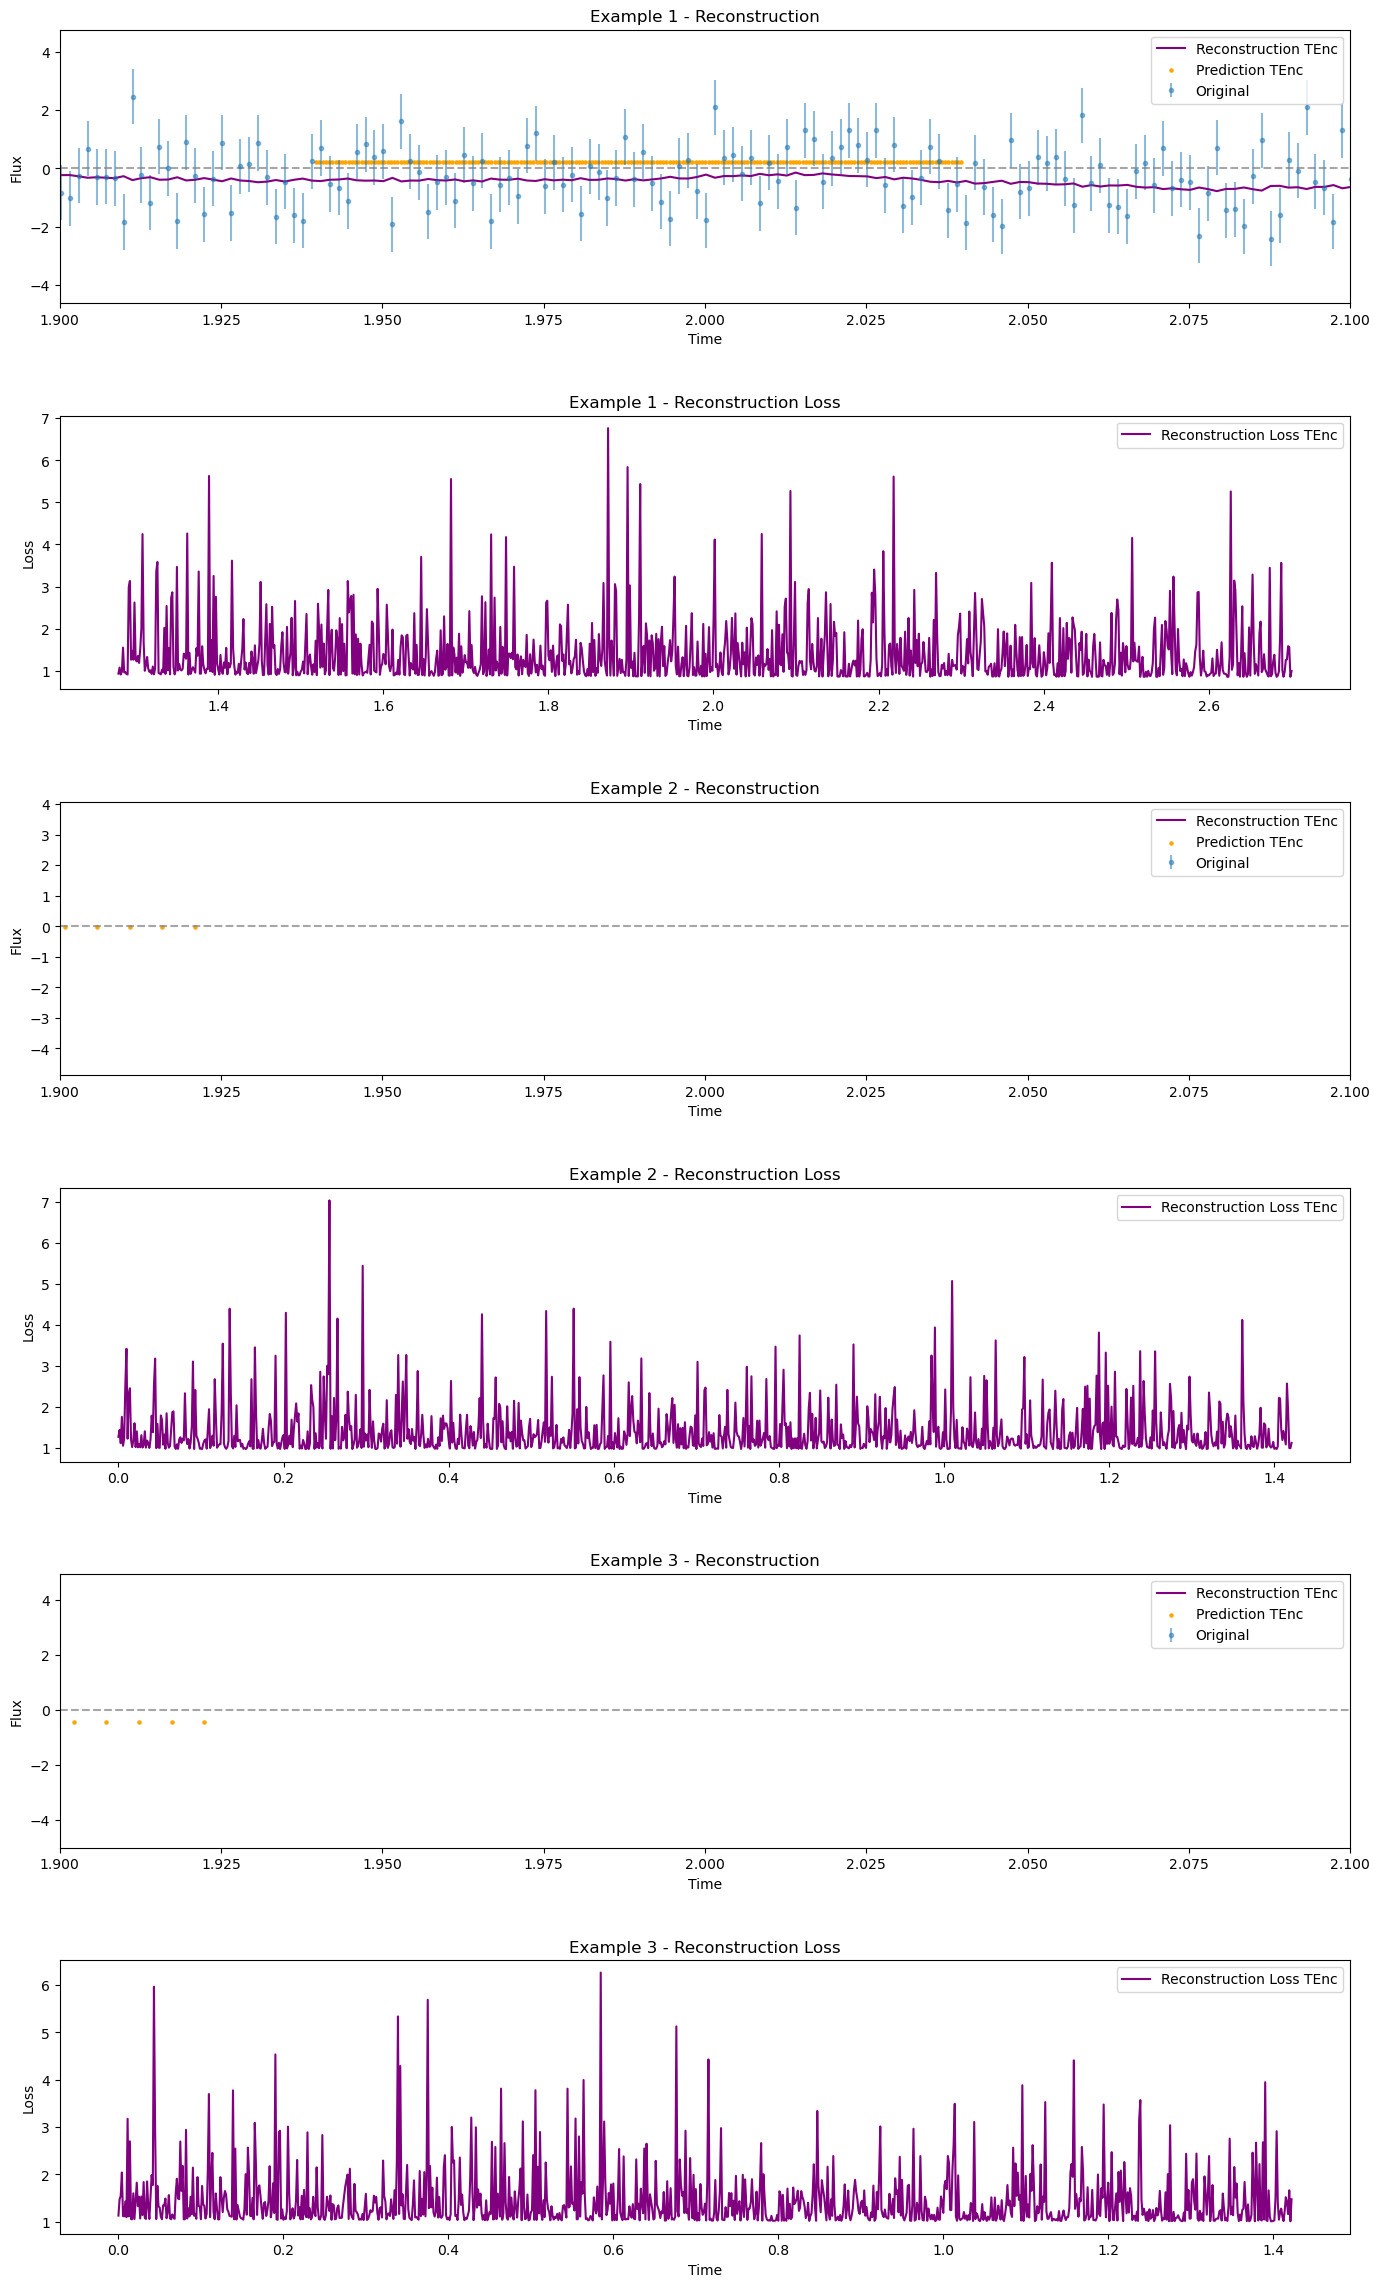

In [22]:
fig, ax = plt.subplots(num_examples*2,1,figsize=(15, num_examples * 8))
plt.tight_layout(pad=6.0)

for i in range(num_examples):

    # Reconstruction
    plt.subplot(num_examples*2,1,(i*2)+1)
    plt.errorbar(times_tenc[i], flux_tenc[i], yerr=flux_err_tenc[i], fmt='.', label='Original', alpha=0.5)
    plt.plot(times_tenc[i], mean_tenc[i], label='Reconstruction TEnc', color='purple')
    plt.scatter(t_pred_tenc[i], pred_tenc[i,:,0], label='Prediction TEnc', color='orange',s=5)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
    plt.title(f'Example {i+1} - Reconstruction')
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.xlim(1.9,2.1)
    plt.legend()

    # Loss
    plt.subplot(num_examples*2,1,(i*2)+2)
    # plt.plot(times_fwd[i], loss_fwd[i], label='Reconstruction Loss Fwd', color='green')
    # plt.plot(times_bwd[i], loss_bwd[i], label='Reconstruction Loss Bwd', color='blue')
    plt.plot(times_tenc[i], loss_tenc[i], label='Reconstruction Loss TEnc', color='purple')
    plt.title(f'Example {i+1} - Reconstruction Loss')
    plt.xlabel('Time')
    plt.ylabel('Loss')
    plt.legend()

plt.show()

### Plot subsequences

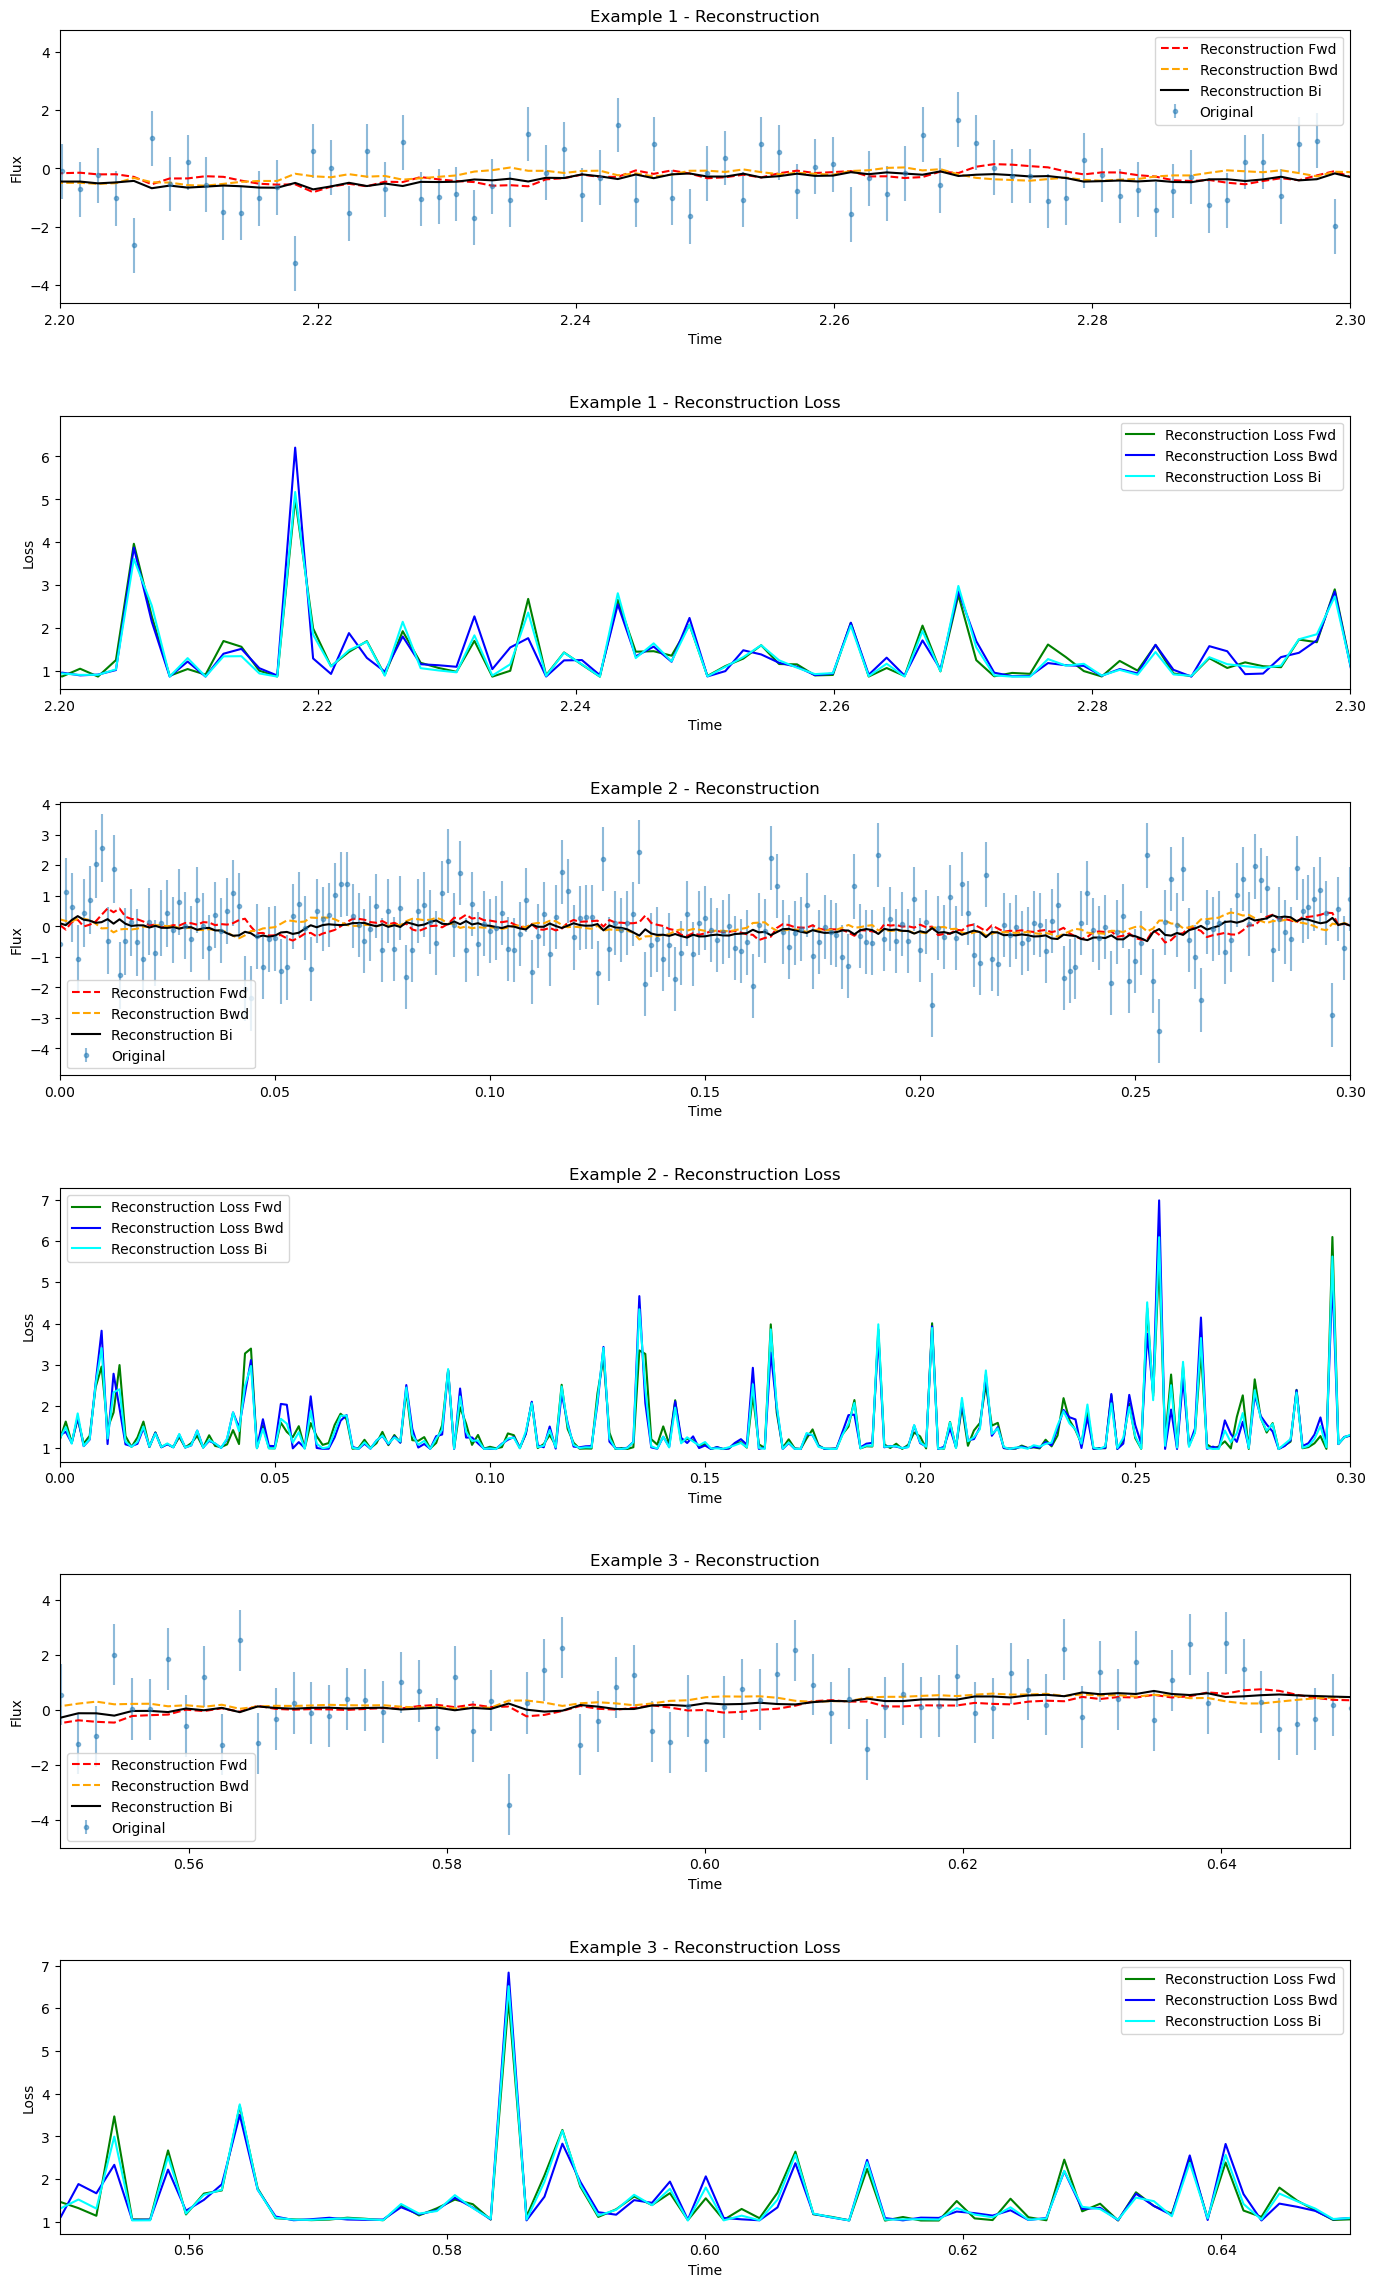

In [10]:
zoom_times = [
    (2.2, 2.3),
    (0, 0.3),
    (0.55, 0.65)
]

fig, ax = plt.subplots(num_examples*2,1,figsize=(15, num_examples * 8))
plt.tight_layout(pad=6.0)

for i in range(num_examples):

    # Reconstruction
    plt.subplot(num_examples*2,1,(i*2)+1)
    plt.errorbar(times_fwd[i], flux_fwd[i], yerr=flux_err_fwd[i], fmt='.', label='Original', alpha=0.5)
    plt.plot(times_fwd[i], mean_fwd[i], label='Reconstruction Fwd', color='red',linestyle='--')
    plt.plot(times_bwd[i], mean_bwd[i], label='Reconstruction Bwd', color='orange',linestyle='--')
    plt.plot(times_bi[i], mean_bi[i], label='Reconstruction Bi', color='black')
    plt.title(f'Example {i+1} - Reconstruction')
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.xlim(zoom_times[i])
    plt.legend()

    # Loss
    plt.subplot(num_examples*2,1,(i*2)+2)
    plt.plot(times_fwd[i], loss_fwd[i], label='Reconstruction Loss Fwd', color='green')
    plt.plot(times_bwd[i], loss_bwd[i], label='Reconstruction Loss Bwd', color='blue')
    plt.plot(times_bi[i], loss_bi[i], label='Reconstruction Loss Bi', color='cyan')
    plt.title(f'Example {i+1} - Reconstruction Loss')
    plt.xlabel('Time')
    plt.ylabel('Loss')
    plt.xlim(zoom_times[i])
    plt.legend()

plt.show()

## Testing Time Encoding